In [ ]:
import tensorflow as tf
import pandas as pd


def read_tensorboard_data(log_dir):
    data = []
    for event_file in tf.io.gfile.glob(f"{log_dir}/events.out.tfevents.*"):
        for event in tf.compat.v1.train.summary_iterator(event_file):
            for value in event.summary.value:
                data.append({"step": event.step, "tag": value.tag, "value": value.simple_value})
    return pd.DataFrame(data)


log_dir = "../training_scripts/runs/e2e_training_logs"
df = read_tensorboard_data(log_dir)
df = df[df["tag"] == "episode/reward"]

In [2]:
import numpy as np


def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), "valid") / window_size


x = np.array(df["step"])
y = np.array(df["value"])

window_size = 10  # Adjust this value to control the smoothing level
y_smoothed = moving_average(y, window_size)
x_smoothed = x[window_size - 1 :]

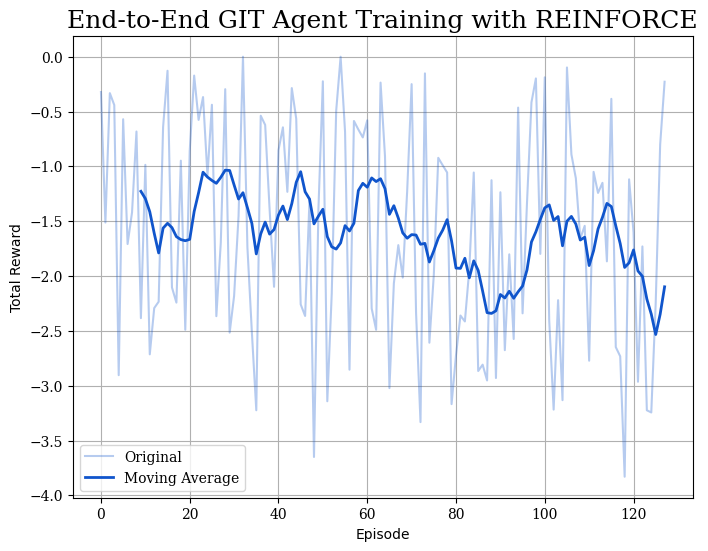

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(x, y, label="Original", alpha=0.3, color="#1055cc")
plt.plot(x_smoothed, y_smoothed, label="Moving Average", linewidth=2, color="#1055cc")
plt.yticks(font="serif")
plt.xticks(font="serif")
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 17
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.title("End-to-End GIT Agent Training with REINFORCE", fontdict={"family": "serif"})
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend(prop="serif")
plt.savefig("./figures/e2e_git_training_reinforce.pdf", format="pdf", bbox_inches="tight")